# 🤖 Train Model - Sonar Returns Classification
**Bài toán:** Binary Classification – Mine (M) vs Rock (R)  
**Dataset dùng xuyên suốt:** sonar.csv  
**Mục tiêu mới:** chọn model tốt nhất dựa trên Accuracy, F1 và ROC_AUC


## Bước 5: Khởi tạo thí nghiệm

In [1]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, pickle, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

TRAIN_DATA_NAME = 'sonar'

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'prj' else os.getcwd()
EXP_DIR    = os.path.join(BASE_DIR, 'exps_', TRAIN_DATA_NAME)
MODEL_DIR  = os.path.join(BASE_DIR, 'model', TRAIN_DATA_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_LOG  = os.path.join(EXP_DIR, 'train_log.xlsx')
META_PATH  = os.path.join(EXP_DIR, 'split_metadata.json')
N_SPLITS   = 5
RANDOM_STATE = 42

FILES = {
    'raw':      (os.path.join(EXP_DIR, 'train_raw.csv'),      os.path.join(EXP_DIR, 'test_raw.csv')),
    'minmax':   (os.path.join(EXP_DIR, 'train_minmax.csv'),   os.path.join(EXP_DIR, 'test_minmax.csv')),
    'standard': (os.path.join(EXP_DIR, 'train_standard.csv'), os.path.join(EXP_DIR, 'test_standard.csv')),
}

SCORING = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, pos_label='M'),
    'roc_auc': 'roc_auc'
}
METRIC_WEIGHTS = {'accuracy': 0.4, 'f1': 0.3, 'roc_auc': 0.3}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   TRAIN_DATA_NAME : {TRAIN_DATA_NAME}')
print(f'   EXP_DIR         : {EXP_DIR}')
print(f'   MODEL_DIR       : {MODEL_DIR}')
print(f'   CV              : {N_SPLITS}-Fold Stratified')
print(f'   Metrics         : {", ".join(SCORING.keys())}')
if os.path.exists(META_PATH):
    with open(META_PATH, 'r', encoding='utf-8') as f:
        split_meta = json.load(f)
    print(f'   Split metadata  : OK ({split_meta.get("train_size")} train / {split_meta.get("test_size_rows")} test)')
else:
    print('   Split metadata  : chưa thấy split_metadata.json')


✅ Khai báo thư viện và tham số xong!
   TRAIN_DATA_NAME : sonar
   EXP_DIR         : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar
   MODEL_DIR       : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\model\sonar
   CV              : 5-Fold Stratified
   Metrics         : accuracy, f1, roc_auc
   Split metadata  : OK (145 train / 63 test)


## Bước 6: Dữ liệu kiểm nghiệm

In [2]:
def load_data(train_path, test_path):
    train = pd.read_csv(train_path)
    test  = pd.read_csv(test_path)
    X_train = train.iloc[:, :-1].values
    y_train = train.iloc[:, -1].values
    X_test  = test.iloc[:, :-1].values
    y_test  = test.iloc[:, -1].values
    return X_train, X_test, y_train, y_test

print('=== KIỂM TRA DỮ LIỆU ===')
for scaler_name, (train_path, test_path) in FILES.items():
    X_tr, X_te, y_tr, y_te = load_data(train_path, test_path)
    print(f'[{scaler_name:8s}] Train: {X_tr.shape} | Test: {X_te.shape} | Classes: {np.unique(y_tr)}')
print()
print('✅ Dữ liệu từ EDA đã sẵn sàng cho train!')


=== KIỂM TRA DỮ LIỆU ===
[raw     ] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']
[minmax  ] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']
[standard] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']

✅ Dữ liệu từ EDA đã sẵn sàng cho train!


## Bước 7: Lượng giá thuật toán
### 7.1 Baselines – 10 model tham số mặc định

In [3]:
def get_candidate_models():
    return [
        ('kNN',               KNeighborsClassifier()),
        ('Naive Bayes',       GaussianNB()),
        ('SVM',               SVC(probability=True, random_state=RANDOM_STATE)),
        ('Decision Tree',     DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ('Random Forest',     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        ('AdaBoost',          AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        ('Gradient Boosting', GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ('Extra Trees',       ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE)),
        ('LDA',               LinearDiscriminantAnalysis()),
        ('MLP',               MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=RANDOM_STATE)),
        ('Logistic Reg.',     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]

def summarize_cv(name, scaler_name, cv_result, model_type='Baseline', params='default'):
    row = {
        'Scaler': scaler_name,
        'Model': name,
        'Loại': model_type,
        'Accuracy': round(cv_result['test_accuracy'].mean(), 4),
        'Acc Std': round(cv_result['test_accuracy'].std(), 4),
        'F1': round(cv_result['test_f1'].mean(), 4),
        'F1 Std': round(cv_result['test_f1'].std(), 4),
        'ROC_AUC': round(cv_result['test_roc_auc'].mean(), 4),
        'AUC Std': round(cv_result['test_roc_auc'].std(), 4),
        'Params': params,
    }
    row['Composite'] = round(
        METRIC_WEIGHTS['accuracy'] * row['Accuracy'] +
        METRIC_WEIGHTS['f1'] * row['F1'] +
        METRIC_WEIGHTS['roc_auc'] * row['ROC_AUC'], 4
    )
    return row

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    print()
    print(f'📊 [{scaler_name.upper()}] CV cho các model ứng viên:')
    print(f'  {"Model":<22} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Cmp":>7}')
    print('  ' + '-' * 60)
    for name, model in get_candidate_models():
        result = cross_validate(model, X_train, y_train, cv=skf, scoring=SCORING, n_jobs=-1)
        row = summarize_cv(name, scaler_name, result)
        cv_rows.append(row)
        print(f'  {name:<22} {row["Accuracy"]:>7.4f} {row["F1"]:>7.4f} {row["ROC_AUC"]:>7.4f} {row["Composite"]:>7.4f}')

df_baseline = pd.DataFrame(cv_rows)
print()
print('✅ Đã đánh giá xong nhóm baseline/candidate models!')



📊 [RAW] CV cho các model ứng viên:
  Model                      Acc      F1     AUC     Cmp
  ------------------------------------------------------------
  kNN                     0.7586  0.7851  0.8189  0.7846
  Naive Bayes             0.6690  0.6537  0.7808  0.6980
  SVM                     0.7586  0.7949  0.8564  0.7988
  Decision Tree           0.6966  0.7013  0.6977  0.6983
  Random Forest           0.8138  0.8423  0.9191  0.8539
  AdaBoost                0.8276  0.8394  0.9206  0.8590
  Gradient Boosting       0.8207  0.8434  0.9244  0.8586
  Extra Trees             0.8483  0.8672  0.9440  0.8827
  LDA                     0.7793  0.7918  0.8107  0.7925
  MLP                     0.8552  0.8738  0.9025  0.8750
  Logistic Reg.           0.7862  0.8060  0.8344  0.8066

📊 [MINMAX] CV cho các model ứng viên:
  Model                      Acc      F1     AUC     Cmp
  ------------------------------------------------------------
  kNN                     0.7931  0.8144  0.8467  0.8156
 

  kNN                     0.7586  0.7851  0.8189  0.7846


  Naive Bayes             0.6690  0.6537  0.7808  0.6980


  SVM                     0.7586  0.7949  0.8564  0.7988
  Decision Tree           0.6966  0.7013  0.6977  0.6983


  Random Forest           0.8138  0.8423  0.9191  0.8539


...

  Random Forest           0.8138  0.8423  0.9195  0.8541


  AdaBoost                0.8276  0.8394  0.9234  0.8599


  Gradient Boosting       0.8207  0.8434  0.9244  0.8586


  Extra Trees             0.8483  0.8672  0.9440  0.8827
  LDA                     0.7793  0.7918  0.8107  0.7925


  MLP                     0.8483  0.8652  0.9197  0.8748
  Logistic Reg.           0.7862  0.7981  0.8489  0.8086

✅ Đã đánh giá xong nhóm baseline/candidate models!


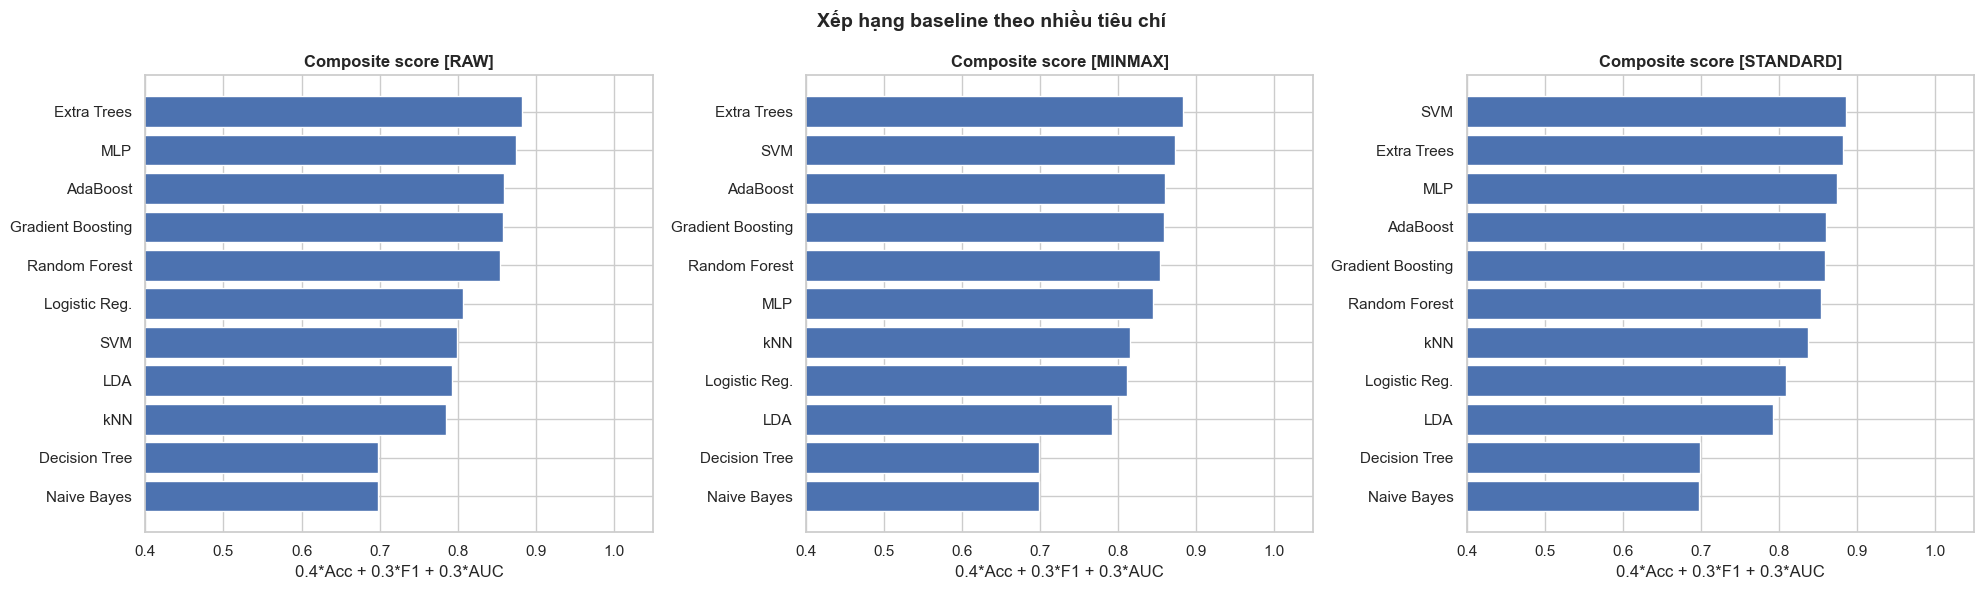

In [4]:
# Biểu đồ composite score của các model baseline
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_baseline[df_baseline['Scaler'] == scaler_name].sort_values('Composite')
    axes[idx].barh(subset['Model'], subset['Composite'])
    axes[idx].set_title(f'Composite score [{scaler_name.upper()}]', fontweight='bold')
    axes[idx].set_xlabel('0.4*Acc + 0.3*F1 + 0.3*AUC')
    axes[idx].set_xlim(0.4, 1.05)
plt.suptitle('Xếp hạng baseline theo nhiều tiêu chí', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_model_composite.png'), bbox_inches='tight')
plt.show()


### 7.2 Tinh chỉnh tham số – SVM & Random Forest

In [5]:
param_grids = {
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [2, 3]
    },
    'Logistic Reg.': {
        'C': [0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'kNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['minkowski', 'manhattan']
    }
}

base_lookup = {name: model for name, model in get_candidate_models()}
tuned_rows = []
best_estimators = {}

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    best_estimators[scaler_name] = {}
    print()
    print(f'🔧 [{scaler_name.upper()}] GridSearch cho nhóm model mạnh:')
    for model_name in ['SVM', 'Random Forest', 'Gradient Boosting', 'Logistic Reg.', 'kNN']:
        grid = GridSearchCV(
            estimator=base_lookup[model_name],
            param_grid=param_grids[model_name],
            scoring='roc_auc',
            cv=skf,
            n_jobs=-1,
            refit=True
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        cv_result = cross_validate(best_model, X_train, y_train, cv=skf, scoring=SCORING, n_jobs=-1)
        row = summarize_cv(f'{model_name} (tuned)', scaler_name, cv_result, model_type='Tuned', params=str(grid.best_params_))
        tuned_rows.append(row)
        best_estimators[scaler_name][f'{model_name} (tuned)'] = best_model
        print(f'  {model_name:<18} Acc={row["Accuracy"]:.4f} | F1={row["F1"]:.4f} | AUC={row["ROC_AUC"]:.4f} | {grid.best_params_}')

df_tuned = pd.DataFrame(tuned_rows)
print()
print('✅ Đã tinh chỉnh xong các model mạnh!')



🔧 [RAW] GridSearch cho nhóm model mạnh:
  SVM                Acc=0.8483 | F1=0.8647 | AUC=0.9063 | {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Random Forest      Acc=0.8069 | F1=0.8339 | AUC=0.9272 | {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 300}
  Gradient Boosting  Acc=0.8483 | F1=0.8679 | AUC=0.9387 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Logistic Reg.      Acc=0.7862 | F1=0.8043 | AUC=0.8584 | {'C': 10, 'solver': 'liblinear'}
  kNN                Acc=0.8414 | F1=0.8553 | AUC=0.8840 | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

🔧 [MINMAX] GridSearch cho nhóm model mạnh:
  SVM                Acc=0.8966 | F1=0.9059 | AUC=0.9473 | {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
  Random Forest      Acc=0.7931 | F1=0.8152 | AUC=0.9272 | {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}
  Gradient Boosting  Acc=0.8483 | F1=0.8679 | AUC=0.9387 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Logis

  Random Forest      Acc=0.8069 | F1=0.8339 | AUC=0.9272 | {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 300}


  Gradient Boosting  Acc=0.8483 | F1=0.8679 | AUC=0.9387 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Logistic Reg.      Acc=0.7862 | F1=0.8043 | AUC=0.8584 | {'C': 10, 'solver': 'liblinear'}


  kNN                Acc=0.8414 | F1=0.8553 | AUC=0.8840 | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

🔧 [MINMAX] GridSearch cho nhóm model mạnh:
  SVM                Acc=0.8966 | F1=0.9059 | AUC=0.9473 | {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


  Random Forest      Acc=0.7931 | F1=0.8152 | AUC=0.9272 | {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}


  Gradient Boosting  Acc=0.8483 | F1=0.8679 | AUC=0.9387 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Logistic Reg.      Acc=0.8000 | F1=0.8136 | AUC=0.8661 | {'C': 10, 'solver': 'lbfgs'}
  kNN                Acc=0.8414 | F1=0.8550 | AUC=0.9115 | {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'distance'}

🔧 [STANDARD] GridSearch cho nhóm model mạnh:


  SVM                Acc=0.8759 | F1=0.8915 | AUC=0.9579 | {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


  Random Forest      Acc=0.8069 | F1=0.8339 | AUC=0.9272 | {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 300}


  Gradient Boosting  Acc=0.8483 | F1=0.8679 | AUC=0.9387 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Logistic Reg.      Acc=0.7793 | F1=0.7928 | AUC=0.8651 | {'C': 0.1, 'solver': 'liblinear'}
  kNN                Acc=0.8483 | F1=0.8620 | AUC=0.9182 | {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

✅ Đã tinh chỉnh xong các model mạnh!


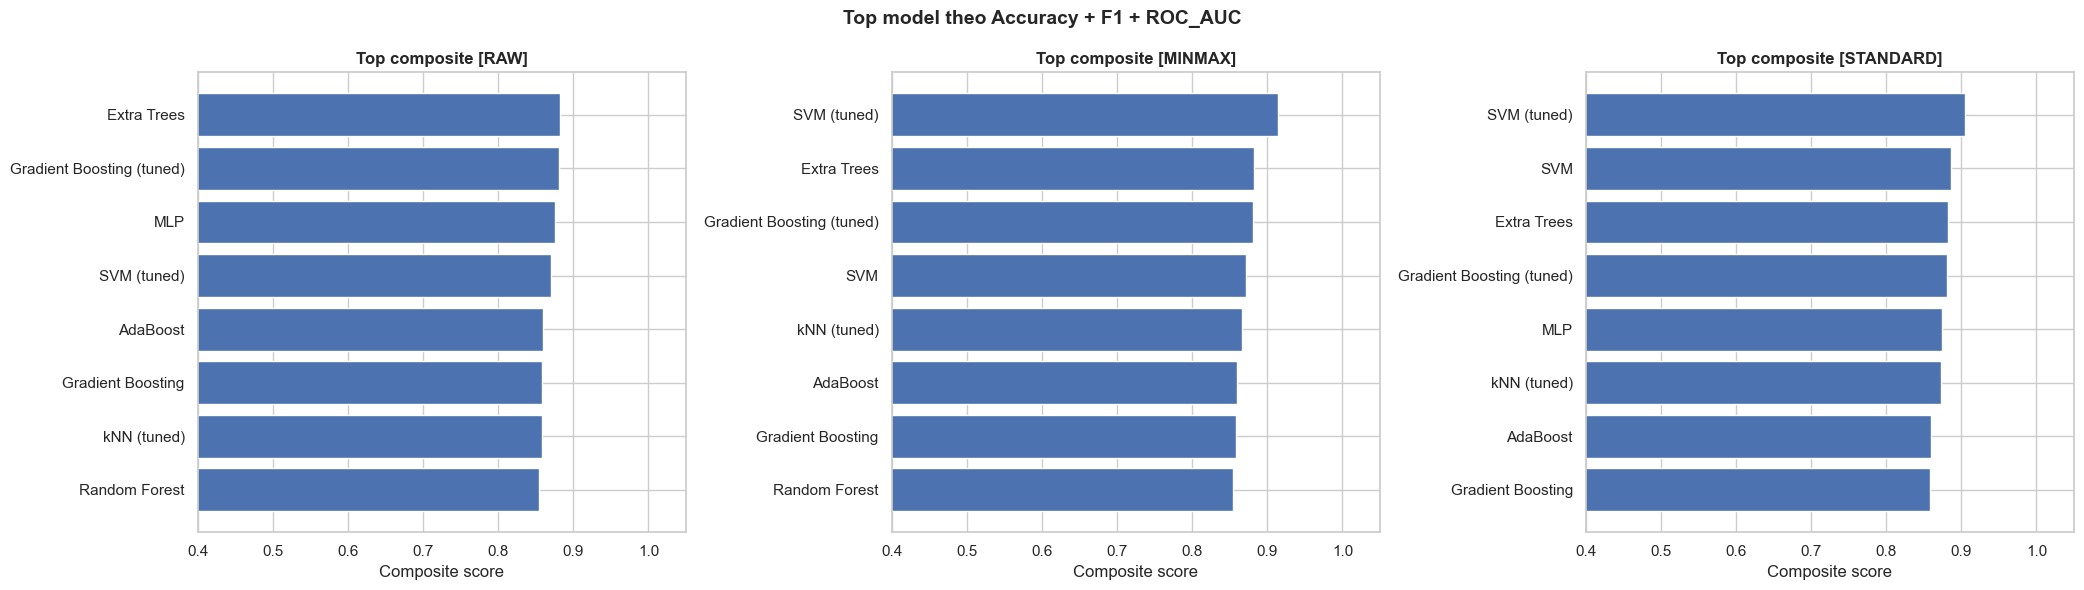

,Scaler,Model,Loại,Accuracy,Acc Std,F1,F1 Std,ROC_AUC,AUC Std,Params,Composite
0,minmax,SVM (tuned),Tuned,0.8966,0.0488,0.9059,0.0440,0.9473,0.0406,"{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}",0.9146
1,standard,SVM (tuned),Tuned,0.8759,0.0710,0.8915,0.0554,0.9579,0.0263,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9052
2,standard,SVM,Baseline,0.8552,0.0703,0.8760,0.0490,0.9387,0.0461,default,0.8865
3,raw,Extra Trees,Baseline,0.8483,0.0560,0.8672,0.0428,0.9440,0.0450,default,0.8827
4,minmax,Extra Trees,Baseline,0.8483,0.0560,0.8672,0.0428,0.9440,0.0450,default,0.8827
5,standard,Extra Trees,Baseline,0.8483,0.0560,0.8672,0.0428,0.9440,0.0450,default,0.8827
6,raw,Gradient Boosting (tuned),Tuned,0.8483,0.0710,0.8679,0.0553,0.9387,0.0451,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.8813
7,minmax,Gradient Boosting (tuned),Tuned,0.8483,0.0710,0.8679,0.0553,0.9387,0.0451,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.8813
8,standard,Gradient Boosting (tuned),Tuned,0.8483,0.0710,0.8679,0.0553,0.9387,0.0451,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.8813
9,raw,MLP,Baseline,0.8552,0.0828,0.8738,0.0720,0.9025,0.0598,default,0.8750


In [6]:
df_kfold_all = pd.concat([df_baseline, df_tuned], ignore_index=True).sort_values(
    ['Composite', 'ROC_AUC', 'F1', 'Accuracy'], ascending=False
).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True)
for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_kfold_all[df_kfold_all['Scaler'] == scaler_name].head(8).copy()
    axes[idx].barh(subset['Model'][::-1], subset['Composite'][::-1])
    axes[idx].set_title(f'Top composite [{scaler_name.upper()}]', fontweight='bold')
    axes[idx].set_xlabel('Composite score')
    axes[idx].set_xlim(0.4, 1.05)
plt.suptitle('Top model theo Accuracy + F1 + ROC_AUC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_top_models_multi_metric.png'), bbox_inches='tight')
plt.show()

df_kfold_all.head(10)


## Bước 8: Train toàn bộ & Lưu model

Tất cả mô hình được fit lại trên **toàn bộ tập train** để tạo phiên bản cuối cùng.
Notebook vẫn **so sánh top 2 model** ngay trong bước train nhằm phục vụ báo cáo,
nhưng chỉ export **duy nhất 1 file** `best_model.pkl` để bước test sử dụng.


In [7]:
all_estimators = {}

for scaler_name, (train_path, _) in FILES.items():
    train_df = pd.read_csv(train_path)
    X_train = train_df.iloc[:, :-1].values
    y_train = train_df.iloc[:, -1].values
    print()
    print(f'[{scaler_name.upper()}] Fit model cuối cùng trên toàn bộ tập train:')

    for name, model in get_candidate_models():
        model.fit(X_train, y_train)
        key = f'{scaler_name}__{name}'
        all_estimators[key] = model
        print(f'   ✅ {name}')

    for tune_name, estimator in best_estimators.get(scaler_name, {}).items():
        estimator.fit(X_train, y_train)
        key = f'{scaler_name}__{tune_name}'
        all_estimators[key] = estimator
        print(f'   ✅ {tune_name}')

# ── So sánh top-2 theo Composite score từ K-Fold ─────────────────
top2 = []
for _, row in df_kfold_all.iterrows():
    key = f'{row["Scaler"]}__{row["Model"]}'
    if key in all_estimators:
        top2.append({
            'rank'     : len(top2) + 1,
            'name'     : row['Model'],
            'scaler'   : row['Scaler'],
            'accuracy' : float(row['Accuracy']),
            'f1'       : float(row['F1']),
            'roc_auc'  : float(row['ROC_AUC']),
            'composite': float(row['Composite']),
            'est'      : all_estimators[key],
        })
    if len(top2) == 2:
        break

best_name = top2[0]['name']
best_scaler = top2[0]['scaler']
best_bundle = {
    'model': top2[0]['est'],
    'model_name': best_name,
    'scaler_name': best_scaler,
    'cv_metrics': {
        'Accuracy': top2[0]['accuracy'],
        'F1': top2[0]['f1'],
        'ROC_AUC': top2[0]['roc_auc'],
        'Composite': top2[0]['composite'],
    }
}

best_path = os.path.join(MODEL_DIR, f'{TRAIN_DATA_NAME}__best_model.pkl')
with open(best_path, 'wb') as f:
    pickle.dump(best_bundle, f)

print()
print('📊 So sánh Top 2 model (K-Fold):')
print(f'  {"":4} {"Model":<26} {"Scaler":<10} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Composite":>10}')
print('  ' + '-' * 74)
for item in top2:
    tag = '← dùng để TEST' if item['rank'] == 1 else '← tham chiếu'
    print(f'  #{item["rank"]:<3} {item["name"]:<26} {item["scaler"]:<10} {item["accuracy"]:>7.4f} {item["f1"]:>7.4f} {item["roc_auc"]:>7.4f} {item["composite"]:>10.4f}  {tag}')

print()
print(f'🏆 Best model: {best_name} [{best_scaler}]')
print(f'💾 Đã lưu duy nhất: {os.path.basename(best_path)}')
print('   Bundle: model + model_name + scaler_name + cv_metrics')



[RAW] Fit model cuối cùng trên toàn bộ tập train:
   ✅ kNN
   ✅ Naive Bayes
   ✅ SVM
   ✅ Decision Tree
   ✅ Random Forest
   ✅ AdaBoost
   ✅ Gradient Boosting
   ✅ Extra Trees
   ✅ LDA
   ✅ MLP
   ✅ Logistic Reg.
   ✅ SVM (tuned)
   ✅ Random Forest (tuned)
   ✅ Gradient Boosting (tuned)
   ✅ Logistic Reg. (tuned)
   ✅ kNN (tuned)

[MINMAX] Fit model cuối cùng trên toàn bộ tập train:
   ✅ kNN
   ✅ Naive Bayes
   ✅ SVM
   ✅ Decision Tree
   ✅ Random Forest
   ✅ AdaBoost
   ✅ Gradient Boosting
   ✅ Extra Trees
   ✅ LDA
   ✅ MLP
   ✅ Logistic Reg.
   ✅ SVM (tuned)
   ✅ Random Forest (tuned)
   ✅ Gradient Boosting (tuned)
   ✅ Logistic Reg. (tuned)
   ✅ kNN (tuned)

[STANDARD] Fit model cuối cùng trên toàn bộ tập train:
   ✅ kNN
   ✅ Naive Bayes
   ✅ SVM
   ✅ Decision Tree
   ✅ Random Forest
   ✅ AdaBoost
   ✅ Gradient Boosting
   ✅ Extra Trees
   ✅ LDA
   ✅ MLP
   ✅ Logistic Reg.
   ✅ SVM (tuned)
   ✅ Random Forest (tuned)
   ✅ Gradient Boosting (tuned)
   ✅ Logistic Reg. (tuned)
   ✅ kN

   ✅ Random Forest


   ✅ AdaBoost


   ✅ Gradient Boosting


   ✅ Extra Trees
   ✅ LDA


...

   ✅ Gradient Boosting


   ✅ Extra Trees
   ✅ LDA
   ✅ MLP
   ✅ Logistic Reg.


   ✅ SVM (tuned)


   ✅ Random Forest (tuned)


   ✅ Gradient Boosting (tuned)
   ✅ Logistic Reg. (tuned)
   ✅ kNN (tuned)

📊 So sánh Top 2 model (K-Fold):
       Model                      Scaler         Acc      F1     AUC  Composite
  --------------------------------------------------------------------------
  #1   SVM (tuned)                minmax      0.8966  0.9059  0.9473     0.9146  ← dùng để TEST
  #2   SVM (tuned)                standard    0.8759  0.8915  0.9579     0.9052  ← tham chiếu

🏆 Best model: SVM (tuned) [minmax]
💾 Đã lưu duy nhất: sonar__best_model.pkl
   Bundle: model + model_name + scaler_name + cv_metrics


## Bước 9: Ghi train_log.xlsx

In [8]:
from openpyxl import load_workbook

summary_row = pd.DataFrame([{
    'Thời gian': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Dataset': TRAIN_DATA_NAME,
    'K-Fold': N_SPLITS,
    'Best model': best_name,
    'Best scaler': best_scaler,
    'Accuracy': top2[0]['accuracy'],
    'F1': top2[0]['f1'],
    'ROC_AUC': top2[0]['roc_auc'],
    'Composite': top2[0]['composite'],
    'Model folder': MODEL_DIR,
}])

if os.path.exists(TRAIN_LOG):
    try:
        old = pd.read_excel(TRAIN_LOG, sheet_name='Lich_su_chay')
        history = pd.concat([old, summary_row], ignore_index=True)
        is_new = False
    except Exception:
        history = summary_row
        is_new = True
else:
    history = summary_row
    is_new = True

with pd.ExcelWriter(TRAIN_LOG, engine='openpyxl', mode='w') as writer:
    history.to_excel(writer, sheet_name='Lich_su_chay', index=False)
    df_baseline.to_excel(writer, sheet_name='Baseline', index=False)
    df_tuned.to_excel(writer, sheet_name='Tuned', index=False)
    df_kfold_all.to_excel(writer, sheet_name='Tat_ca_model', index=False)
    pd.DataFrame([best_bundle['cv_metrics']]).to_excel(writer, sheet_name='Best_model', index=False)

print(('🆕 Tạo mới' if is_new else '➕ Cập nhật') + f': {TRAIN_LOG}')
wb = load_workbook(TRAIN_LOG)
print('Các sheet:', ', '.join(wb.sheetnames))
wb.close()


➕ Cập nhật: D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_log.xlsx
Các sheet: Lich_su_chay, Baseline, Tuned, Tat_ca_model, Best_model


## Tổng kết thực nghiệm

In [9]:
print('=' * 70)
print('TỔNG KẾT TRAIN - SONAR')
print('=' * 70)
print(f'Dataset            : {TRAIN_DATA_NAME}')
print(f'Số model đã so sánh: {len(all_estimators)}')
print(f'Best model         : {best_name}')
print(f'Best scaler        : {best_scaler}')
print(f'Accuracy           : {top2[0]["accuracy"]:.4f}')
print(f'F1                 : {top2[0]["f1"]:.4f}')
print(f'ROC_AUC            : {top2[0]["roc_auc"]:.4f}')
print(f'Composite          : {top2[0]["composite"]:.4f}')
print(f'File export        : {TRAIN_DATA_NAME}__best_model.pkl')
print('=' * 70)
print('➡ Bước tiếp theo: chạy 03_test.ipynb để test chính thức trên file test từ EDA')


TỔNG KẾT TRAIN - SONAR
Dataset            : sonar
Số model đã so sánh: 48
Best model         : SVM (tuned)
Best scaler        : minmax
Accuracy           : 0.8966
F1                 : 0.9059
ROC_AUC            : 0.9473
Composite          : 0.9146
File export        : sonar__best_model.pkl
➡ Bước tiếp theo: chạy 03_test.ipynb để test chính thức trên file test từ EDA
